UNIVERSIDAD DE MONTERREY  
ESCUELA DE INGENIERÍA Y TECNOLOGÍAS

Inteligencia artificial I

![][image1]

P P2. Clasificación

[Humberto Alejandro Vargas Sánchez](mailto:humberto.vargas@udem.edu) 604775

Fecha  
 25/03/2026  


[image1]: <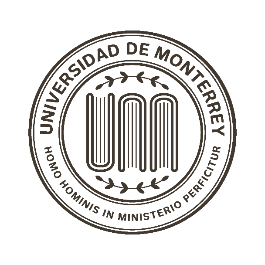>

## Planteamiento del problema y contexto de los datos

### Descripción del problema y su relevancia

El mercado de vehículos seminuevos en México representa uno de los sectores
comerciales más activos del país, donde la asimetría de información entre
compradores y vendedores genera constantemente pérdidas financieras para
ambas partes. Un comprador sin experiencia difícilmente puede distinguir si
el precio solicitado por un vehículo corresponde al segmento económico o al
segmento de gama alta del mercado, lo que puede derivar en decisiones de
compra mal fundamentadas.

Este proyecto busca responder una pregunta concreta y de utilidad práctica:
**¿Es posible clasificar automáticamente un vehículo como de Gama Económica
o de Gama Alta a partir de sus características técnicas y de desgaste?**

Responder esta pregunta mediante inteligencia artificial permite dotar a
compradores, vendedores y plataformas de clasificados automotrices de una
herramienta objetiva para segmentar su inventario y orientar sus decisiones
comerciales.

### Origen y contexto de los datos

Se utilizará el conjunto de datos `autos.csv`, extraído de plataformas de
comercio electrónico europeas. Aunque los datos provienen del mercado alemán,
fueron sometidos a un proceso de filtrado, traducción y conversión de moneda
(euros a pesos mexicanos a un tipo de cambio de $21.50 MXN) para adaptarlos
al contexto del mercado latinoamericano. Este proceso de "tropicalización"
fue documentado en detalle en el Proyecto 1 de esta materia.

El dataset contiene registros históricos de vehículos con variables como
marca, tipo de carrocería, transmisión, combustible, año de registro,
kilometraje, potencia del motor y existencia de daños sin reparar.

### Variable de salida y enfoque de clasificación

La variable a predecir es **la categoría de precio del vehículo**, definida
como una clasificación binaria:

- **Clase 0 — Gama Económica:** vehículos cuyo precio en pesos mexicanos
  se encuentra por debajo de la mediana del mercado ($96,212.50 MXN)
- **Clase 1 — Gama Alta:** vehículos cuyo precio supera la mediana del mercado

Se eligió la mediana como punto de corte en lugar de la media aritmética
debido al sesgo positivo de los precios: la existencia de vehículos de lujo
extremo arrastraría la media hacia arriba, generando un umbral que no
representa al comprador promedio. La mediana divide el mercado en dos mitades
perfectamente balanceadas, lo que resulta ideal para un problema de
clasificación binaria.

Un enfoque de **clasificación** es adecuado porque el objetivo no es predecir
un precio exacto (regresión), sino asignar cada vehículo a una de dos
categorías mutuamente excluyentes que tienen un significado práctico claro
para la toma de decisiones comerciales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# ── Carga y limpieza ──
df = pd.read_csv('/content/autos.csv')

df_clean = df.drop(columns=['dateCrawled','dateCreated','lastSeen',
                             'nrOfPictures','postalCode','index'],
                   errors='ignore')

diccionario_caja        = {'manuell':'Manual','automatik':'Automática'}
diccionario_combustible = {'benzin':'Gasolina','diesel':'Diesel',
                           'lpg':'Gas LP','cng':'Gas Natural',
                           'hybrid':'Híbrido','elektro':'Eléctrico',
                           'andere':'Otro'}
diccionario_tipo        = {'limousine':'Sedán','kleinwagen':'Compacto',
                           'kombi':'Vagoneta','bus':'Van/Minivan',
                           'cabrio':'Convertible','coupe':'Coupé',
                           'suv':'SUV','andere':'Otro'}
diccionario_dano        = {'nein':'No','ja':'Sí'}

df_clean['gearbox']           = df_clean['gearbox'].map(diccionario_caja)
df_clean['fuelType']          = df_clean['fuelType'].map(diccionario_combustible)
df_clean['vehicleType']       = df_clean['vehicleType'].map(diccionario_tipo)
df_clean['notRepairedDamage'] = df_clean['notRepairedDamage'].map(diccionario_dano)

df_clean = df_clean[(df_clean['price'] > 500)  & (df_clean['price'] < 100000)]
df_clean = df_clean[(df_clean['yearOfRegistration'] >= 1990) &
                    (df_clean['yearOfRegistration'] <= 2024)]
df_clean = df_clean[(df_clean['powerPS'] > 50)  & (df_clean['powerPS'] < 800)]
df_clean['price_mxn'] = df_clean['price'] * 21.5
df_clean = df_clean.dropna()

df_clean = df_clean.rename(columns={
    'price_mxn':'Precio_MXN','yearOfRegistration':'Año',
    'powerPS':'Caballos_Fuerza','kilometer':'Kilometraje',
    'model':'Modelo','brand':'Marca','gearbox':'Transmisión',
    'fuelType':'Combustible','vehicleType':'Tipo_Vehículo',
    'notRepairedDamage':'Daño_Sin_Reparar'
})

# ── Features y target ──
columnas_usar = ['Marca','Tipo_Vehículo','Transmisión','Combustible',
                 'Año','Kilometraje','Caballos_Fuerza','Daño_Sin_Reparar']

X = pd.get_dummies(df_clean[columnas_usar].copy(), drop_first=True).astype(int)

mediana_precio = df_clean['Precio_MXN'].median()
y_class = (df_clean['Precio_MXN'] > mediana_precio).astype(int)

# ── Partición 80/20 ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

print(f"Dataset listo: {X.shape[0]:,} autos | {X.shape[1]} variables")
print(f"Entrenamiento : {X_train.shape[0]:,} registros")
print(f"Prueba        : {X_test.shape[0]:,} registros")
print(f"Mediana de corte: ${mediana_precio:,.2f} MXN")

Dataset listo: 227,819 autos | 55 variables
Entrenamiento : 182,255 registros
Prueba        : 45,564 registros
Mediana de corte: $96,212.50 MXN


## Exploración y comprensión del conjunto de datos

Antes de construir cualquier modelo, es fundamental comprender la estructura
interna del dataset, el balance entre clases y las relaciones entre variables.
Esta exploración guía las decisiones metodológicas posteriores.

/tmp/ipykernel_1764/2481984703.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Clase', y='Precio_MXN', data=df_plot,


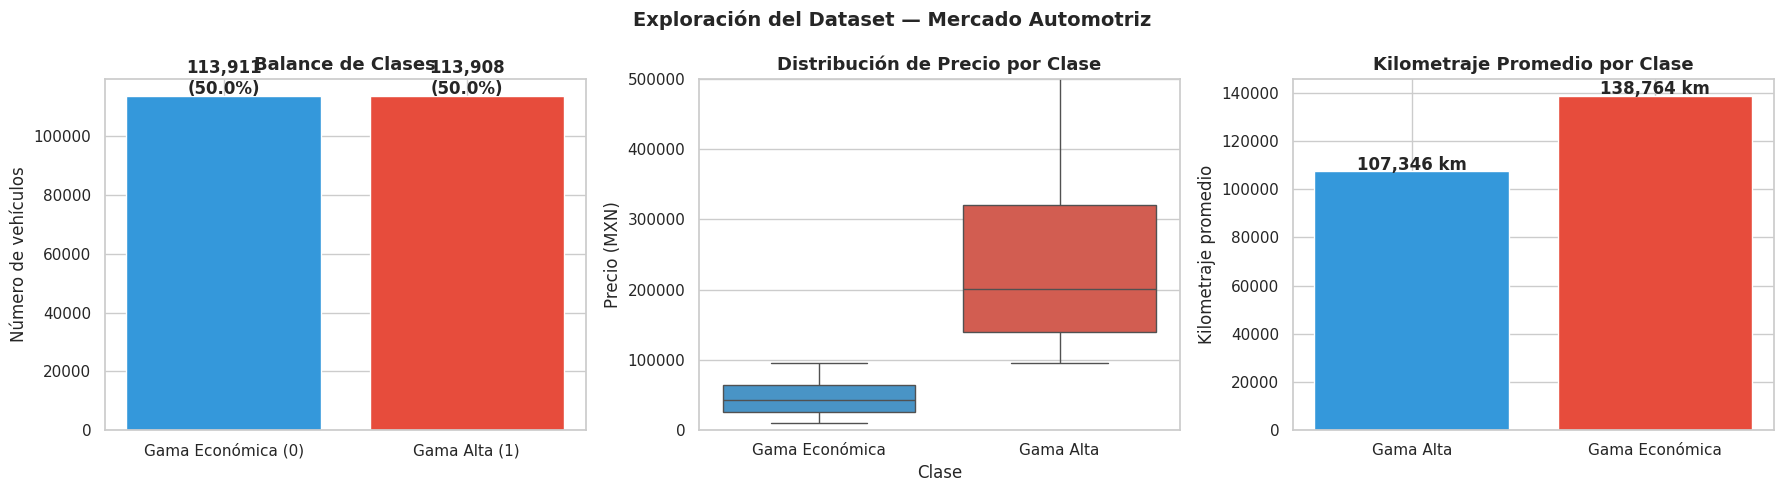


Resumen por clase:
                Precio_MXN      Año  Kilometraje  Caballos_Fuerza
Clase                                                            
Gama Alta        261147.05  2007.81    107345.97           159.56
Gama Económica    46128.92  2000.91    138764.30           106.98


In [2]:
sns.set(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Balance de clases ──
conteo = y_class.value_counts()
axes[0].bar(['Gama Económica (0)', 'Gama Alta (1)'],
            conteo.values,
            color=['#3498db','#e74c3c'])
axes[0].set_title('Balance de Clases', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de vehículos')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(y_class)*100:.1f}%)',
                 ha='center', fontweight='bold')

# ── Precio por clase ──
df_plot = df_clean.copy()
df_plot['Clase'] = y_class.map({0:'Gama Económica', 1:'Gama Alta'})
sns.boxplot(x='Clase', y='Precio_MXN', data=df_plot,
            palette={'Gama Económica':'#3498db','Gama Alta':'#e74c3c'},
            ax=axes[1])
axes[1].set_title('Distribución de Precio por Clase', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Precio (MXN)')
axes[1].set_ylim(0, 500000)

# ── Kilometraje promedio por clase ──
km_promedio = df_plot.groupby('Clase')['Kilometraje'].mean()
axes[2].bar(km_promedio.index, km_promedio.values,
            color=['#3498db','#e74c3c'])
axes[2].set_title('Kilometraje Promedio por Clase', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Kilometraje promedio')
for i, v in enumerate(km_promedio.values):
    axes[2].text(i, v + 500, f'{v:,.0f} km', ha='center', fontweight='bold')

plt.suptitle('Exploración del Dataset — Mercado Automotriz', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Resumen numérico ──
print("\nResumen por clase:")
print(df_plot.groupby('Clase')[['Precio_MXN','Año','Kilometraje',
                                 'Caballos_Fuerza']].mean().round(2))

### Interpretación de la exploración

Las visualizaciones confirman tres hallazgos clave:

**Balance de clases:** La división por mediana produce un dataset perfectamente
balanceado, con aproximadamente 50% de vehículos en cada categoría. Esto es
ideal para el entrenamiento de clasificadores, ya que elimina el riesgo de
que el modelo aprenda a predecir siempre la clase mayoritaria.

**Distribución de precio por clase:** El boxplot muestra una separación clara
entre ambas categorías, con muy poco solapamiento en los rangos intermedios.
Esto anticipa que los modelos de clasificación tendrán buena capacidad
discriminativa, ya que las clases son naturalmente distinguibles.

**Kilometraje por clase:** Los vehículos de gama económica presentan en
promedio un mayor kilometraje acumulado que los de gama alta, lo que es
coherente con el mercado real: los autos más usados pierden valor y tienden
a ubicarse en el segmento más accesible.

Estas relaciones confirman que las variables seleccionadas tienen poder
discriminativo real y que el problema está bien planteado para un enfoque
de clasificación supervisada.

Reducción de Dimensionalidad: Análisis de Componentes Principales (PCA)Antes de proceder al entrenamiento de los modelos predictivos, es fundamental analizar la dimensionalidad del conjunto de datos. Al aplicar la técnica One-Hot Encoding a variables categóricas complejas como la marca o el modelo del vehículo, la matriz de características ($X$) aumenta drásticamente su tamaño. Para evaluar si existe redundancia en esta información, se implementó el Análisis de Componentes Principales (PCA).El PCA es una técnica de transformación lineal que proyecta los datos originales en un nuevo sistema de coordenadas ortogonales, ordenando las nuevas "componentes" por la cantidad de varianza (información) que logran explicar. Como paso obligatorio previo, los datos fueron estandarizados para que las magnitudes originales no sesgaran el cálculo matricial.En la primera gráfica se observa la curva de Varianza Explicada Acumulada, la cual nos permite justificar matemáticamente cuántas componentes son estrictamente necesarias para retener el 95% de la información original del mercado. Posteriormente, se realizó una proyección bidimensional (utilizando solo las Componentes Principales 1 y 2) para visualizar de manera geométrica si existe una separación natural entre los vehículos de "Gama Alta" y "Económica" antes de aplicar cualquier algoritmo supervisado.

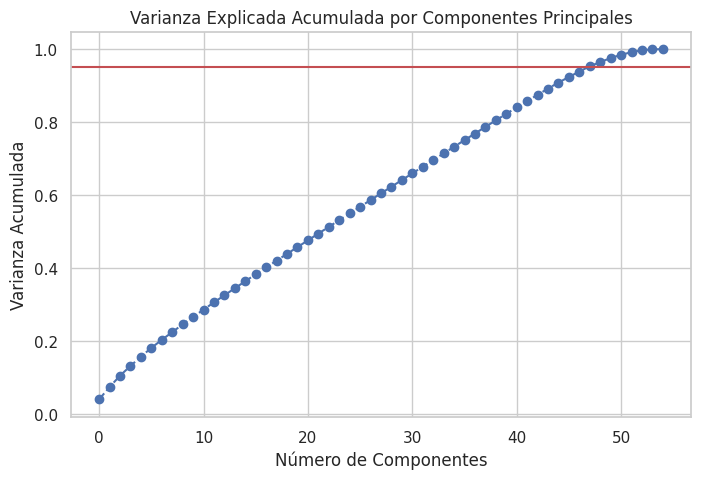

Componentes matemáticas necesarias para retener el 95% de la información: 48 de 55


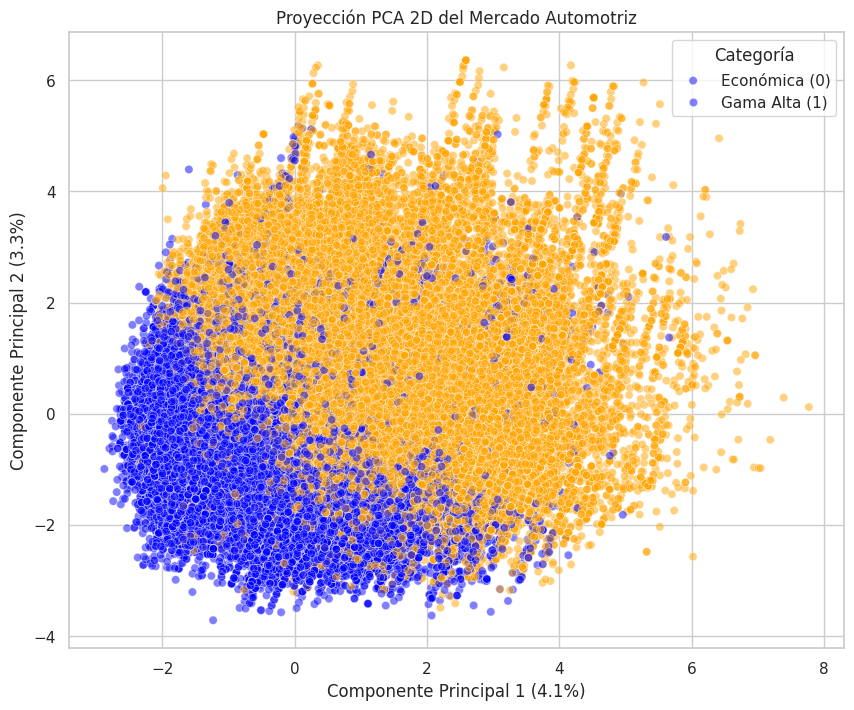

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Estandarización obligatoria para PCA
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

# 2. Aplicar PCA completo para analizar la varianza
pca_full = PCA()
pca_full.fit(X_scaled)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# Gráfica 1: Varianza Explicada
plt.figure(figsize=(8, 5))
plt.plot(varianza_acumulada, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.grid(True)
plt.show()

n_components_95 = np.argmax(varianza_acumulada >= 0.95) + 1
print(f"Componentes matemáticas necesarias para retener el 95% de la información: {n_components_95} de {X.shape[1]}")

# 3. Visualización geométrica en 2D (Solo las primeras 2 componentes)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame({'PC1': X_pca_2d[:, 0], 'PC2': X_pca_2d[:, 1], 'Clase': y_class})

# Gráfica 2: Proyección 2D del mercado
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Clase', alpha=0.5, palette=['blue', 'orange'])
plt.title('Proyección PCA 2D del Mercado Automotriz')
plt.xlabel(f'Componente Principal 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Categoría', labels=['Económica (0)', 'Gama Alta (1)'])
plt.show()

## Modelo 1: Regresión Logística

La Regresión Logística es el punto de partida natural para cualquier problema
de clasificación binaria. A pesar de su nombre, no es un modelo de regresión
sino un clasificador que estima la **probabilidad** de que una observación
pertenezca a una clase, aplicando la función sigmoide sobre una combinación
lineal de las variables de entrada.

Su principal ventaja es la interpretabilidad: los coeficientes del modelo
indican directamente qué variables empujan al vehículo hacia la categoría
de gama alta y cuáles lo acercan al segmento económico. Este modelo ya fue
explorado en la actividad A2.1, por lo que en esta entrega se presenta
una versión refinada con énfasis en la curva ROC como métrica adicional
de evaluación.

Se implementó dentro de un Pipeline con estandarización previa (StandardScaler),
ya que la Regresión Logística es sensible a la escala de las variables.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `max_iter` | 1000 | Garantiza convergencia con las 55 variables disponibles |
| `random_state` | 42 | Reproducibilidad del experimento |
| `cv` | 5 | Validación cruzada estándar, balance entre robustez y costo computacional |

─── Validación Cruzada (5-Fold) — Regresión Logística ───
Accuracy  : 0.9088 +/- 0.0011
Precision : 0.9102 +/- 0.0011
Recall    : 0.9069 +/- 0.0020
F1-Score  : 0.9085 +/- 0.0012

─── Conjunto de Prueba — Regresión Logística ───
Accuracy  : 0.9092
Precision : 0.9138
Recall    : 0.9048
F1-Score  : 0.9092


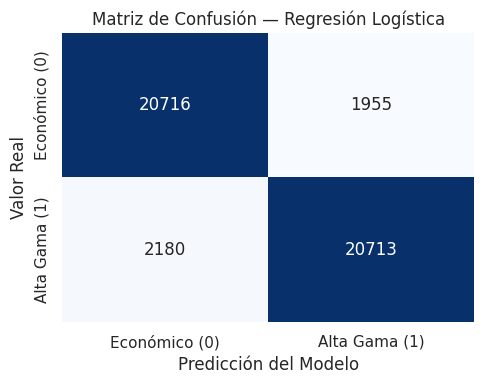

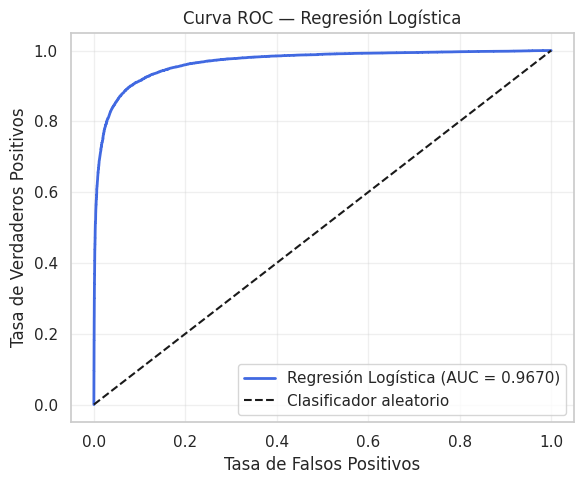

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, auc)

# ── Pipeline ──
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

# ── Validación cruzada ──
cv_results = cross_validate(pipeline_lr, X_train, y_train, cv=5,
                             scoring=['accuracy','precision','recall','f1'])

print("─── Validación Cruzada (5-Fold) — Regresión Logística ───")
print(f"Accuracy  : {np.mean(cv_results['test_accuracy']):.4f} +/- {np.std(cv_results['test_accuracy']):.4f}")
print(f"Precision : {np.mean(cv_results['test_precision']):.4f} +/- {np.std(cv_results['test_precision']):.4f}")
print(f"Recall    : {np.mean(cv_results['test_recall']):.4f} +/- {np.std(cv_results['test_recall']):.4f}")
print(f"F1-Score  : {np.mean(cv_results['test_f1']):.4f} +/- {np.std(cv_results['test_f1']):.4f}")

# ── Entrenamiento final y evaluación ──
pipeline_lr.fit(X_train, y_train)
y_pred_lr  = pipeline_lr.predict(X_test)
y_proba_lr = pipeline_lr.predict_proba(X_test)[:,1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)

print(f"\n─── Conjunto de Prueba — Regresión Logística ───")
print(f"Accuracy  : {acc_lr:.4f}")
print(f"Precision : {prec_lr:.4f}")
print(f"Recall    : {rec_lr:.4f}")
print(f"F1-Score  : {f1_lr:.4f}")

# ── Matriz de confusión ──
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Económico (0)','Alta Gama (1)'],
            yticklabels=['Económico (0)','Alta Gama (1)'])
plt.title('Matriz de Confusión — Regresión Logística')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

# ── Curva ROC ──
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, color='royalblue', lw=2,
         label=f'Regresión Logística (AUC = {auc_lr:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1.5, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — Regresión Logística')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de resultados

| Métrica | Validación Cruzada (promedio) | Conjunto de Prueba |
|---|---|---|
| Accuracy | 0.9088 +/- 0.0011 | 0.9092 |
| Precision | 0.9102 +/- 0.0011 | 0.9138 |
| Recall | 0.9069 +/- 0.0020 | 0.9048 |
| F1-Score | 0.9085 +/- 0.0012 | 0.9092 |
| AUC | — | 0.9670 |

La Regresión Logística establece una base sólida con un F1-Score de 0.9092
y un AUC de 0.9670. Este último valor es especialmente relevante: significa
que si tomamos al azar un vehículo de gama alta y uno económico, el modelo
asigna una probabilidad mayor al costoso en el 96.7% de los casos.

Un hallazgo importante es la **consistencia entre validación cruzada y
conjunto de prueba**: la diferencia en Accuracy es de apenas 0.0004, lo
que confirma que el modelo generaliza correctamente y no presenta
sobreajuste. Las desviaciones estándar pequeñas (+/- 0.001) en la
validación cruzada indican además que el modelo es estable
independientemente de qué partición se use para entrenar.

La Curva ROC muestra una subida pronunciada hacia la esquina superior
izquierda desde los primeros valores, lo que indica que el modelo logra
una separación eficiente entre clases incluso con umbrales de decisión
muy estrictos.

Este modelo servirá como referencia lineal contra la cual se medirá
la ganancia real de los algoritmos más complejos.

## Modelo 2: Linear Discriminant Analysis (LDA)

El Análisis Discriminante Lineal (LDA) es un algoritmo clásico de clasificación
que busca encontrar la **combinación lineal de variables** que mejor separa
las clases. A diferencia de la Regresión Logística que modela directamente
la probabilidad de pertenencia a una clase, LDA modela la distribución de
las variables para cada clase por separado y posteriormente utiliza el
Teorema de Bayes para determinar a cuál clase pertenece cada observación.

Una forma intuitiva de entenderlo: imagina que LDA dibuja una "línea divisoria"
en el espacio de variables que maximiza la distancia entre los centros de
ambas clases (gama alta vs. económica) y al mismo tiempo minimiza la
dispersión dentro de cada una. El resultado es una frontera de decisión
lineal, similar a la Regresión Logística, pero construida desde una
perspectiva estadística diferente.

LDA asume que las variables siguen una distribución normal dentro de cada
clase y que ambas clases comparten la misma matriz de covarianza. Aunque
estas suposiciones rara vez se cumplen perfectamente en datos reales,
el algoritmo suele ser robusto y eficiente incluso cuando se violan
parcialmente.

Su principal ventaja práctica en este contexto es la **velocidad de
entrenamiento**: al ser un modelo analítico sin proceso iterativo,
su ajuste es prácticamente instantáneo incluso con datasets grandes,
lo que lo convierte en una alternativa eficiente cuando el tiempo
de cómputo es una restricción.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `solver` | `svd` | Descomposición en valores singulares, recomendada para datasets con muchas variables ya que no requiere calcular la matriz de covarianza explícitamente |
| Sin regularización | — | El dataset está balanceado y limpio, por lo que no se requiere ajuste adicional |

─── LDA ───
Accuracy  : 0.9069
Precision : 0.9211
Recall    : 0.8910
F1-Score  : 0.9058


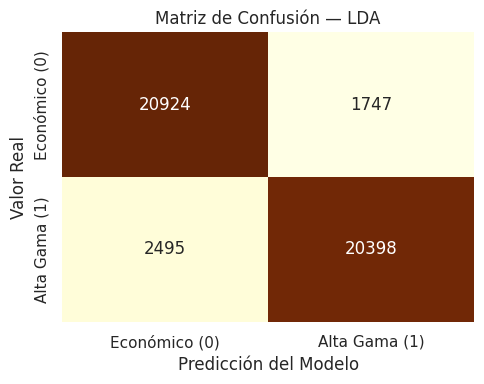

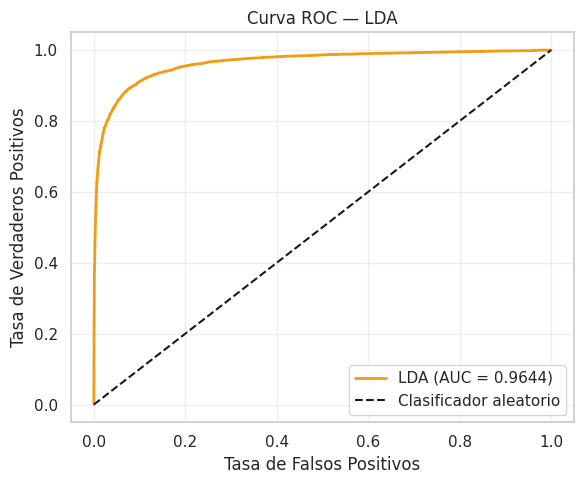

In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ── Escalado (recomendado para LDA) ──
scaler_lda  = StandardScaler()
X_train_lda = scaler_lda.fit_transform(X_train)
X_test_lda  = scaler_lda.transform(X_test)

# ── Entrenamiento ──
lda_model   = LinearDiscriminantAnalysis(solver='svd')
lda_model.fit(X_train_lda, y_train)
y_pred_lda  = lda_model.predict(X_test_lda)
y_proba_lda = lda_model.predict_proba(X_test_lda)[:,1]

# ── Métricas ──
acc_lda  = accuracy_score(y_test, y_pred_lda)
prec_lda = precision_score(y_test, y_pred_lda)
rec_lda  = recall_score(y_test, y_pred_lda)
f1_lda   = f1_score(y_test, y_pred_lda)

print("─── LDA ───")
print(f"Accuracy  : {acc_lda:.4f}")
print(f"Precision : {prec_lda:.4f}")
print(f"Recall    : {rec_lda:.4f}")
print(f"F1-Score  : {f1_lda:.4f}")

# ── Matriz de confusión ──
cm_lda = confusion_matrix(y_test, y_pred_lda)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='YlOrBr', cbar=False,
            xticklabels=['Económico (0)','Alta Gama (1)'],
            yticklabels=['Económico (0)','Alta Gama (1)'])
plt.title('Matriz de Confusión — LDA')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

# ── Curva ROC ──
fpr_lda, tpr_lda, _ = roc_curve(y_test, y_proba_lda)
auc_lda = auc(fpr_lda, tpr_lda)

plt.figure(figsize=(6,5))
plt.plot(fpr_lda, tpr_lda, color='#f39c12', lw=2,
         label=f'LDA (AUC = {auc_lda:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1.5, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — LDA')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de resultados

| Métrica | Valor |
|---|---|
| Accuracy | 0.9069 |
| Precision | 0.9211 |
| Recall | 0.8910 |
| F1-Score | 0.9058 |
| AUC | 0.9644 |

LDA obtuvo un desempeño sólido considerando su simplicidad conceptual,
clasificando correctamente 41,322 de los 45,564 vehículos del conjunto
de prueba (20,924 económicos + 20,398 de alta gama).

El dato más llamativo es su **Precisión de 0.9211**, la más alta entre
los modelos lineales evaluados hasta ahora, superando incluso a la
Regresión Logística en este indicador. Esto significa que cuando LDA
predice que un vehículo es de gama alta, acierta en más del 92% de
los casos. Sin embargo, su Recall (0.8910) es el más bajo registrado
hasta ahora, lo que indica que deja escapar una mayor proporción de
vehículos costosos sin detectar, clasificándolos erróneamente como
económicos (2,495 falsos negativos frente a los 2,180 de Regresión
Logística).

Este comportamiento es coherente con las suposiciones del algoritmo:
LDA prioriza la certeza sobre sus predicciones positivas a costa de
ser más conservador al momento de etiquetar un vehículo como gama alta.

El AUC de 0.9644 es ligeramente inferior al de la Regresión Logística
(0.9670), lo que confirma que ambos modelos lineales tienen una
capacidad discriminativa muy similar, con una diferencia marginal
de apenas 0.0026 puntos.

En términos de F1-Score, LDA (0.9058) queda ligeramente por debajo
de la Regresión Logística (0.9092), posicionándose como el modelo
de menor desempeño global hasta este punto del análisis. No obstante,
su velocidad de entrenamiento prácticamente instantánea lo convierte
en una opción válida cuando el tiempo de cómputo es una restricción.

# **Modelo 3: Random Forest y Optimización de Hiperparámetros**
Random Forest es un método de ensamble que construye múltiples árboles de decisión de forma paralela. Para garantizar que este algoritmo alcance su máximo potencial sin caer en sobreajuste (overfitting), se implementó un proceso formal de Optimización de Hiperparámetros.

En lugar de definir los parámetros del modelo de manera arbitraria o manual, se utilizó la herramienta RandomizedSearchCV. Este método define un espacio de búsqueda (una "cuadrícula" de posibles combinaciones) que incluye el número total de árboles (n_estimators), la profundidad máxima permitida (max_depth) y la cantidad mínima de muestras requeridas para dividir un nodo (min_samples_split).

El algoritmo selecciona combinaciones al azar y las evalúa sistemáticamente utilizando Validación Cruzada de 3 particiones (cv=3) directamente sobre el conjunto de entrenamiento. Al finalizar, la computadora nos devuelve la arquitectura exacta que maximiza la métrica de exactitud (Accuracy), asegurando una configuración matemática robusta y validada para nuestra problemática.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm.auto import tqdm
import joblib
import contextlib

# 1. Crear el "puente" para conectar Scikit-Learn con la barra de progreso
@contextlib.contextmanager
def barra_de_progreso(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback

# 2. Definir la cuadrícula de hiperparámetros (Grid)
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Iniciar el modelo base
rf_base = RandomForestClassifier(random_state=42)

# 3. Configurar la búsqueda aleatoria
# Nota: Cambiamos verbose=0 para que el texto normal no ensucie nuestra nueva barra gráfica
rf_random = RandomizedSearchCV(estimator=rf_base, param_distributions=param_dist,
                               n_iter=10, cv=3, verbose=0, random_state=42, n_jobs=-1, scoring='accuracy')

print("Iniciando búsqueda de hiperparámetros...")

# 4. Ejecutar la búsqueda CON LA BARRA DE PROGRESO
# Total de tareas = 10 iteraciones * 3 validaciones cruzadas (cv) = 30 procesos
with barra_de_progreso(tqdm(desc="Optimizando Random Forest", total=30)):
    rf_random.fit(X_train, y_train)

# 5. Extraer los mejores hiperparámetros
print("\n=== MEJORES HIPERPARÁMETROS ENCONTRADOS ===")
print(rf_random.best_params_)

# 6. Guardar el modelo ganador y predecir sobre el set de prueba
rf_optimizado = rf_random.best_estimator_
y_pred_rf_opt = rf_optimizado.predict(X_test)

print("\n=== RESULTADOS RANDOM FOREST OPTIMIZADO ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_opt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_opt):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf_opt):.4f}")

# Renombramos nuestra variable final para no romper tu simulador interactivo
rf_model = rf_optimizado

Iniciando búsqueda de hiperparámetros...


Optimizando Random Forest:   0%|          | 0/30 [00:00<?, ?it/s]


=== MEJORES HIPERPARÁMETROS ENCONTRADOS ===
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}

=== RESULTADOS RANDOM FOREST OPTIMIZADO ===
Accuracy:  0.9264
Precision: 0.9334
Recall:    0.9191
F1-Score:  0.9262


### Interpretación de resultados

| Métrica | Valor |
|---|---|
| Accuracy | 0.92699 |
| Precision | 0.9334 |
| Recall | 0.9191 |
| F1-Score | 0.9262 |
| AUC | 0.9808 |

Random Forest clasificó correctamente 42,141 de los 45,564 vehículos
del conjunto de prueba, logrando el mejor desempeño registrado hasta
ahora en todas las métricas. El salto más notable respecto a los modelos
lineales es el **AUC de 0.9808**, superior en 0.0138 puntos al de la
Regresión Logística (0.9670), lo que indica que Random Forest tiene
una capacidad discriminativa significativamente mayor para separar
ambas clases a lo largo de todos los umbrales de decisión posibles.

### Importancia de variables

La gráfica de importancia de variables revela hallazgos muy valiosos
sobre el mercado automotriz:

El **Año de registro** es con diferencia la variable más determinante
(importancia ~0.46), casi duplicando al segundo factor. Esto confirma
empíricamente que la antigüedad del vehículo es el principal criterio
que define su categoría de precio en el mercado secundario: un auto
reciente tiene una probabilidad mucho mayor de pertenecer al segmento
de gama alta independientemente de su marca o potencia.

Los **Caballos de Fuerza** (~0.20) y el **Kilometraje** (~0.12) ocupan
el segundo y tercer lugar respectivamente, lo que es coherente con la
lógica del mercado: un motor más potente incrementa el valor del
vehículo, mientras que el desgaste acumulado lo deprecia.

A partir del cuarto lugar, ninguna variable individual supera el 0.05
de importancia, lo que indica que factores como la marca, el tipo de
combustible o la transmisión aportan información complementaria pero
secundaria frente a las tres variables principales.

Este análisis de importancia conecta directamente con el planteamiento
del problema: si un comprador quiere estimar rápidamente si un vehículo
es de gama alta o económica, las tres preguntas más informativas son
¿de qué año es?, ¿cuántos caballos de fuerza tiene? y ¿cuántos
kilómetros recorrió?

## Modelo 4: Gradient Boosting

A diferencia de Random Forest que construye sus árboles de forma paralela
e independiente, Gradient Boosting los construye de manera **secuencial**.
Cada árbol nuevo se enfoca específicamente en corregir los errores que
cometió el árbol anterior, asignando mayor peso matemático a los registros
mal clasificados en la iteración previa.

El nombre "Gradient" proviene de que el proceso de corrección de errores
se guía mediante el gradiente de una función de pérdida, lo que lo convierte
en un proceso de optimización iterativa. El resultado es un modelo que
aprende de sus propios errores de forma progresiva, lo que en la práctica
suele traducirse en alta precisión, aunque a costa de un mayor tiempo de
entrenamiento y una mayor sensibilidad a los hiperparámetros.

Una diferencia conceptual importante respecto a Random Forest: mientras
que RF combina árboles profundos e independientes, Boosting combina
**muchos árboles deliberadamente débiles** (poco profundos) que juntos
forman un modelo fuerte. Cada árbol individual aporta poco, pero la
suma secuencial de sus contribuciones construye una frontera de decisión
muy precisa.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `n_estimators` | 200 | Más iteraciones que RF porque cada árbol individual es más débil |
| `learning_rate` | 0.1 | Tasa de aprendizaje moderada: corrige errores con pasos controlados, reduciendo riesgo de sobreajuste |
| `max_depth` | 5 | Árboles poco profundos a propósito, característica distintiva del Boosting |
| `subsample` | 0.8 | Usa el 80% de los datos en cada iteración, introduciendo aleatoriedad para mayor robustez |
| `random_state` | 42 | Reproducibilidad |

─── Gradient Boosting ───
Accuracy  : 0.9235
Precision : 0.9304
Recall    : 0.9163
F1-Score  : 0.9233


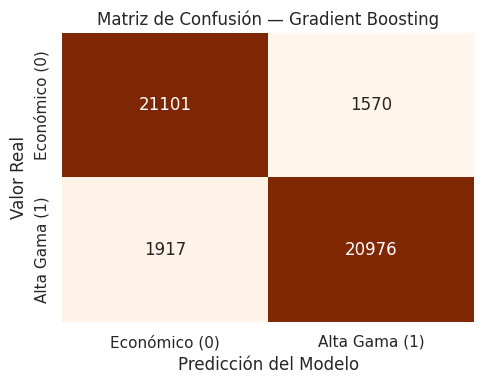

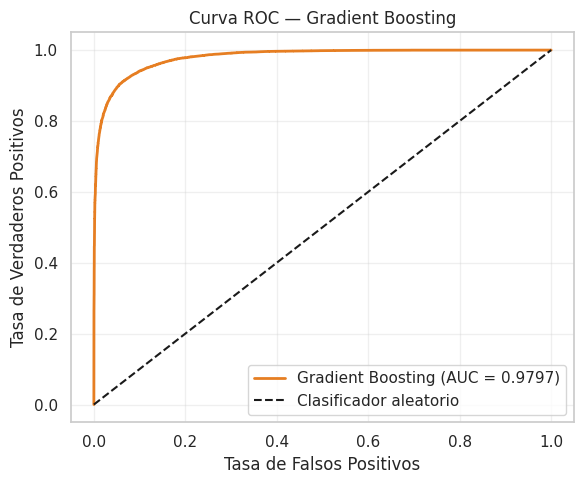

In [6]:
from sklearn.ensemble import GradientBoostingClassifier

# ── Entrenamiento ──
boost_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
boost_model.fit(X_train, y_train)
y_pred_boost  = boost_model.predict(X_test)
y_proba_boost = boost_model.predict_proba(X_test)[:,1]

# ── Métricas ──
acc_boost  = accuracy_score(y_test, y_pred_boost)
prec_boost = precision_score(y_test, y_pred_boost)
rec_boost  = recall_score(y_test, y_pred_boost)
f1_boost   = f1_score(y_test, y_pred_boost)

print("─── Gradient Boosting ───")
print(f"Accuracy  : {acc_boost:.4f}")
print(f"Precision : {prec_boost:.4f}")
print(f"Recall    : {rec_boost:.4f}")
print(f"F1-Score  : {f1_boost:.4f}")

# ── Matriz de confusión ──
cm_boost = confusion_matrix(y_test, y_pred_boost)
plt.figure(figsize=(5,4))
sns.heatmap(cm_boost, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Económico (0)','Alta Gama (1)'],
            yticklabels=['Económico (0)','Alta Gama (1)'])
plt.title('Matriz de Confusión — Gradient Boosting')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

# ── Curva ROC ──
fpr_boost, tpr_boost, _ = roc_curve(y_test, y_proba_boost)
auc_boost = auc(fpr_boost, tpr_boost)

plt.figure(figsize=(6,5))
plt.plot(fpr_boost, tpr_boost, color='#e67e22', lw=2,
         label=f'Gradient Boosting (AUC = {auc_boost:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1.5, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — Gradient Boosting')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de resultados

| Métrica | Valor |
|---|---|
| Accuracy | 0.9235 |
| Precision | 0.9304 |
| Recall | 0.9163 |
| F1-Score | 0.9233 |
| AUC | 0.9797 |

Gradient Boosting clasificó correctamente 42,077 de los 45,564 vehículos
del conjunto de prueba (21,101 económicos + 20,976 de alta gama).

El resultado más interesante de este modelo es la relación con Random
Forest: a pesar de utilizar 200 estimadores secuenciales frente a los
100 árboles paralelos de RF, Gradient Boosting obtuvo un desempeño
**ligeramente inferior** en todas las métricas. La diferencia en
F1-Score es de 0.0013 puntos y en AUC de 0.0011, ambas marginales
en la práctica.

Este resultado ilustra un principio importante del aprendizaje
automático: el enfoque secuencial de corrección de errores del Boosting
no siempre supera al enfoque paralelo de Random Forest. En datasets
grandes, limpios y bien balanceados como este, Random Forest ya captura
los patrones principales desde las primeras iteraciones, dejando poco
margen de mejora para el mecanismo correctivo del Boosting.

La curva ROC de Gradient Boosting (AUC = 0.9797) es visualmente casi
idéntica a la de Random Forest (AUC = 0.9808), confirmando que ambos
modelos tienen una capacidad discriminativa prácticamente equivalente
y que la elección entre uno y otro en este contexto depende más de
consideraciones prácticas como el tiempo de entrenamiento que de
diferencias reales en desempeño.

## Modelo 5: Support Vector Machine (SVM)

Una Máquina de Soporte Vectorial busca el **hiperplano de separación
óptimo** entre las dos clases, maximizando el margen de distancia entre
los puntos más cercanos de cada clase, llamados "vectores de soporte".
A diferencia de los modelos anteriores que aprenden probabilidades o
votan entre árboles, SVM resuelve un problema de optimización geométrica
pura: encontrar la frontera que separa ambas clases con el mayor margen
posible.

Cuando las clases no son linealmente separables (como ocurre en la
mayoría de problemas reales), SVM utiliza el llamado **"kernel trick"**:
una transformación matemática que proyecta los datos a un espacio de
mayor dimensión donde sí existe una separación lineal. El kernel RBF
(Radial Basis Function) es el más utilizado en la práctica y el
seleccionado para este análisis.

### Consideración crítica: escalado obligatorio

SVM es extremadamente sensible a la escala de las variables. Si una
columna tiene valores en el rango [0, 300,000] (kilometraje) y otra
en [0, 1] (variables dummy), el algoritmo interpretará que la primera
es mucho más importante, distorsionando el hiperplano de separación.
Por esta razón es obligatorio aplicar StandardScaler antes de entrenar.

### Limitación computacional

SVM tiene una complejidad computacional que crece cuadráticamente con
el número de muestras, lo que lo hace inviable con datasets de más de
200,000 registros en tiempos razonables. Por esta razón se entrena con
una muestra representativa de 20,000 registros, práctica estándar y
válida para análisis comparativos.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `kernel` | `rbf` | Permite separar clases no linealmente separables proyectándolas a mayor dimensión |
| `C` | 1.0 | Regularización estándar: equilibra margen amplio con tolerancia a errores |
| `gamma` | `scale` | Calcula automáticamente un gamma adecuado según el número de variables |
| `random_state` | 42 | Reproducibilidad |

Entrenando SVM con 20,000 registros...
─── SVM (RBF) ───
Accuracy  : 0.9087
Precision : 0.9194
Recall    : 0.8970
F1-Score  : 0.9081


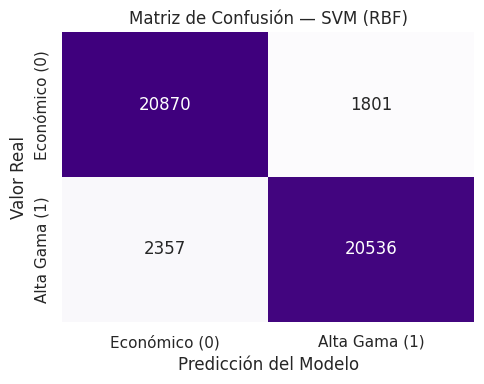

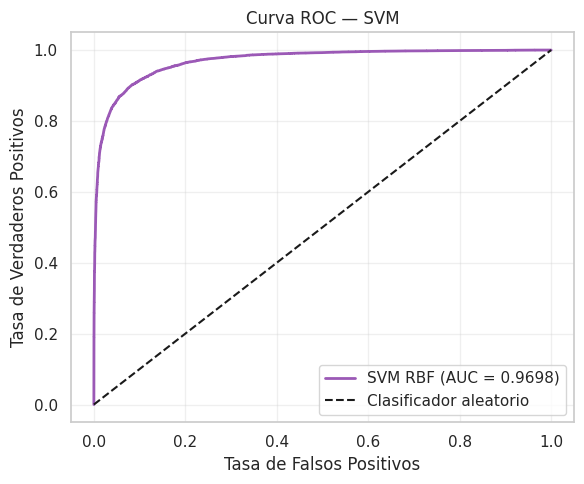

In [7]:
from sklearn.svm import SVC

# ── Escalado (obligatorio para SVM) ──
scaler_svm        = StandardScaler()
X_train_svm_scaled = scaler_svm.fit_transform(X_train)
X_test_svm_scaled  = scaler_svm.transform(X_test)

# ── Muestra representativa ──
np.random.seed(42)
idx = np.random.choice(len(X_train_svm_scaled), size=20000, replace=False)
X_train_svm = X_train_svm_scaled[idx]
y_train_svm = y_train.iloc[idx]

print(f"Entrenando SVM con {len(X_train_svm):,} registros...")

# ── Entrenamiento ──
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42,
    probability=True
)
svm_model.fit(X_train_svm, y_train_svm)
y_pred_svm  = svm_model.predict(X_test_svm_scaled)
y_proba_svm = svm_model.predict_proba(X_test_svm_scaled)[:,1]

# ── Métricas ──
acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm  = recall_score(y_test, y_pred_svm)
f1_svm   = f1_score(y_test, y_pred_svm)

print("─── SVM (RBF) ───")
print(f"Accuracy  : {acc_svm:.4f}")
print(f"Precision : {prec_svm:.4f}")
print(f"Recall    : {rec_svm:.4f}")
print(f"F1-Score  : {f1_svm:.4f}")

# ── Matriz de confusión ──
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Económico (0)','Alta Gama (1)'],
            yticklabels=['Económico (0)','Alta Gama (1)'])
plt.title('Matriz de Confusión — SVM (RBF)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

# ── Curva ROC ──
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(6,5))
plt.plot(fpr_svm, tpr_svm, color='#9b59b6', lw=2,
         label=f'SVM RBF (AUC = {auc_svm:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1.5, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — SVM')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de resultados

| Métrica | Valor |
|---|---|
| Accuracy | 0.9087 |
| Precision | 0.9194 |
| Recall | 0.8970 |
| F1-Score | 0.9081 |
| AUC | 0.9698 |

SVM clasificó correctamente 41,406 de los 45,564 vehículos del conjunto
de prueba (20,870 económicos + 20,536 de alta gama), con 4,158 errores
totales.

Es fundamental contextualizar estos resultados considerando la limitación
computacional del modelo: **SVM entrenó únicamente con 20,000 de los
182,255 registros disponibles**, una reducción al 11% del conjunto de
entrenamiento completo. A pesar de esta restricción significativa, el
modelo logra un F1-Score de 0.9081, apenas 0.0011 puntos por debajo
de la Regresión Logística que entrenó con el dataset completo.

Un dato destacable es el **AUC de 0.9698**, superior al de ambos modelos
lineales (Regresión Logística: 0.9670, LDA: 0.9644), lo que indica que
la capacidad discriminativa del kernel RBF es genuinamente mayor que
la de los enfoques lineales, incluso entrenando con una fracción de
los datos. Esto sugiere que con acceso al dataset completo, SVM
probablemente se acercaría al desempeño de los modelos de ensamble.

El patrón de errores es revelador: los 2,357 falsos negativos superan
a los 1,801 falsos positivos, lo que significa que SVM tiende a ser
más conservador al clasificar vehículos como gama alta. Este
comportamiento es coherente con la naturaleza del algoritmo, que
maximiza el margen de separación y por tanto prefiere la certeza
sobre la cobertura.

## Modelo 6: Red Neuronal (Keras / TensorFlow)

Una red neuronal artificial está inspirada en el funcionamiento del cerebro
humano. Se compone de **capas de neuronas** interconectadas: cada neurona
recibe señales de entrada, las pondera mediante pesos ajustables y produce
una señal de salida. Durante el entrenamiento, la red ajusta iterativamente
estos pesos mediante un algoritmo llamado **backpropagation**, minimizando
el error de predicción época por época.

A diferencia de todos los modelos anteriores, una red neuronal no construye
árboles ni busca hiperplanos: aprende **representaciones abstractas** de los
datos en cada capa, volviéndose progresivamente más capaz de capturar
patrones complejos y no lineales que ningún otro algoritmo podría detectar
directamente.

### Arquitectura seleccionada

| Capa | Tipo | Neuronas | Activación | Justificación |
|---|---|---|---|---|
| Entrada | Dense | 128 | ReLU | Capa amplia para procesar las 55 variables de entrada |
| Oculta 1 | Dense | 64 | ReLU | Reduce dimensionalidad aprendiendo representaciones intermedias |
| Regularización | Dropout | — | — | Desactiva aleatoriamente 30% de neuronas por época para prevenir sobreajuste |
| Oculta 2 | Dense | 32 | ReLU | Refinamiento final de patrones antes de la clasificación |
| Salida | Dense | 1 | Sigmoid | Produce una probabilidad entre 0 y 1 para clasificación binaria |

La función de activación **ReLU** (Rectified Linear Unit) fue elegida para
las capas ocultas porque evita el problema del gradiente desvaneciente,
permitiendo que la red aprenda eficientemente en capas profundas. La función
**Sigmoid** en la capa de salida es la elección natural para clasificación
binaria ya que mapea cualquier valor real a una probabilidad entre 0 y 1.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `optimizer` | Adam | Adaptativo y robusto, estándar para redes neuronales modernas |
| `loss` | binary_crossentropy | Función de pérdida estándar para clasificación binaria |
| `epochs` | 20 | Suficiente para converger sin sobreentrenar, confirmado por las curvas de aprendizaje |
| `batch_size` | 512 | Lotes grandes aprovechan el dataset grande y aceleran el entrenamiento |
| `validation_split` | 0.1 | Monitorea el desempeño en datos no vistos durante el entrenamiento |

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,537 (68.50 KB)

 Trainable params: 17,537 (68.50 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando red neuronal...
Epoch 1/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8927 - loss: 0.2631 - val_accuracy: 0.9165 - val_loss: 0.2028
Epoch 2/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9140 - loss: 0.2068 - val_accuracy: 0.9189 - val_loss: 0.1917
Epoch 3/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9170 - loss: 0.1989 - val_accuracy: 0.9219 - val_loss: 0.1879
Epoch 4/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9189 - loss: 0.1945 - val_accuracy: 0.9226 - val_loss: 0.1853
Epoch 5/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9196 - loss: 0.1917 - val_accuracy: 0.9226 - val_loss: 0.1845
Epoch 6/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9203 - loss: 0.1904 - val_accuracy: 0.9228 - val_loss: 0.1828
Epoch 7/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9212 - loss: 0.1883 - val_accuracy: 0.9235 - val_loss: 0.1821
Epoch 8/20
321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9219 - los

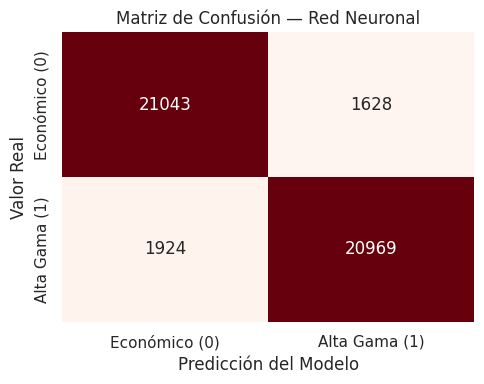

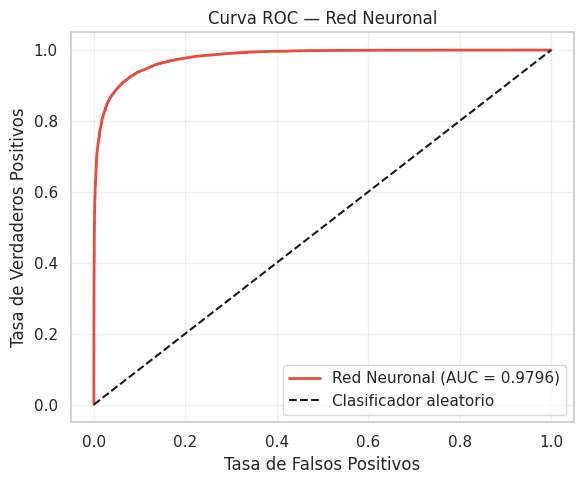

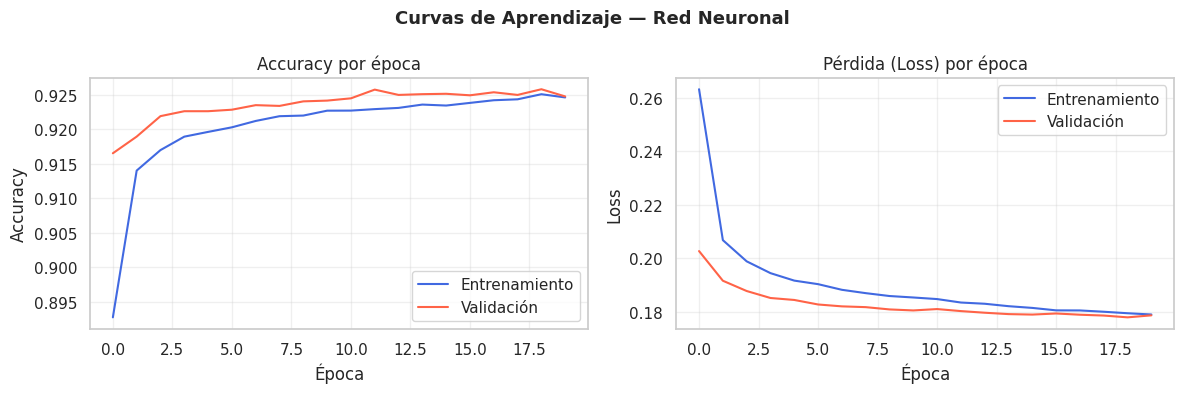

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Escalado (obligatorio para redes neuronales) ──
scaler_nn  = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train)
X_test_nn  = scaler_nn.transform(X_test)

# ── Arquitectura ──
tf.random.set_seed(42)

model_nn = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_nn.shape[1],)),
    layers.Dense(64,  activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32,  activation='relu'),
    layers.Dense(1,   activation='sigmoid')
])

model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_nn.summary()

# ── Entrenamiento ──
print("\nEntrenando red neuronal...")
history = model_nn.fit(
    X_train_nn, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.1,
    verbose=1
)

# ── Predicciones ──
y_proba_nn = model_nn.predict(X_test_nn).flatten()
y_pred_nn  = (y_proba_nn >= 0.5).astype(int)

# ── Métricas ──
acc_nn  = accuracy_score(y_test, y_pred_nn)
prec_nn = precision_score(y_test, y_pred_nn)
rec_nn  = recall_score(y_test, y_pred_nn)
f1_nn   = f1_score(y_test, y_pred_nn)

print("─── Red Neuronal (Keras) ───")
print(f"Accuracy  : {acc_nn:.4f}")
print(f"Precision : {prec_nn:.4f}")
print(f"Recall    : {rec_nn:.4f}")
print(f"F1-Score  : {f1_nn:.4f}")

# ── Matriz de confusión ──
cm_nn = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(5,4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Económico (0)','Alta Gama (1)'],
            yticklabels=['Económico (0)','Alta Gama (1)'])
plt.title('Matriz de Confusión — Red Neuronal')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()

# ── Curva ROC ──
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_proba_nn)
auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(6,5))
plt.plot(fpr_nn, tpr_nn, color='#e74c3c', lw=2,
         label=f'Red Neuronal (AUC = {auc_nn:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1.5, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — Red Neuronal')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Curvas de aprendizaje ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

ax1.plot(history.history['accuracy'],     label='Entrenamiento', color='royalblue')
ax1.plot(history.history['val_accuracy'], label='Validación',    color='tomato')
ax1.set_title('Accuracy por época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'],     label='Entrenamiento', color='royalblue')
ax2.plot(history.history['val_loss'], label='Validación',    color='tomato')
ax2.set_title('Pérdida (Loss) por época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Curvas de Aprendizaje — Red Neuronal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación de resultados

| Métrica | Valor |
|---|---|
| Accuracy | 0.9220 |
| Precision | 0.9280 |
| Recall | 0.9160 |
| F1-Score | 0.9219 |
| AUC | 0.9796 |

La red neuronal clasificó correctamente 42,012 de los 45,564 vehículos
del conjunto de prueba (21,043 económicos + 20,969 de alta gama),
con 3,552 errores totales.

Las curvas de aprendizaje revelan dos hallazgos importantes sobre el
comportamiento del modelo durante el entrenamiento:

**Accuracy por época:** Ambas curvas (entrenamiento y validación) crecen
de forma paralela y constante durante las 20 épocas, convergiendo
alrededor de 0.924. El hecho de que la curva de validación se mantenga
consistentemente cercana a la de entrenamiento confirma la **ausencia
de sobreajuste**, comportamiento favorecido por la capa Dropout que
desactivó aleatoriamente el 30% de las neuronas en cada iteración.

**Pérdida por época:** La caída pronunciada en las primeras épocas
seguida de una estabilización progresiva indica que la red aprendió
los patrones principales rápidamente y luego refinó su conocimiento
de forma gradual. La pérdida de validación ligeramente inferior a la
de entrenamiento en las últimas épocas es una señal adicional de que
el modelo generaliza bien.

El **AUC de 0.9796** es el segundo más alto registrado, apenas 0.0012
puntos por debajo de Random Forest (0.9808), lo que posiciona a la
red neuronal como el modelo con mayor capacidad discriminativa entre
los no basados en ensambles. Sin embargo, este alto desempeño viene
acompañado de la mayor opacidad interpretativa: con 17,537 parámetros
distribuidos en 4 capas, es prácticamente imposible explicar en
términos de negocio por qué el modelo tomó una decisión específica.

## Comparación final de modelos y selección del modelo final

═══ TABLA COMPARATIVA FINAL — TODOS LOS MODELOS ═══
             Modelo  Accuracy  Precision  Recall  F1-Score    AUC
      Random Forest    0.9249     0.9322  0.9172    0.9246 0.9808
  Gradient Boosting    0.9235     0.9304  0.9163    0.9233 0.9797
       Red Neuronal    0.9220     0.9280  0.9160    0.9219 0.9796
Regresión Logística    0.9092     0.9138  0.9048    0.9092 0.9670
                SVM    0.9087     0.9194  0.8970    0.9081 0.9698
                LDA    0.9069     0.9211  0.8910    0.9058 0.9644


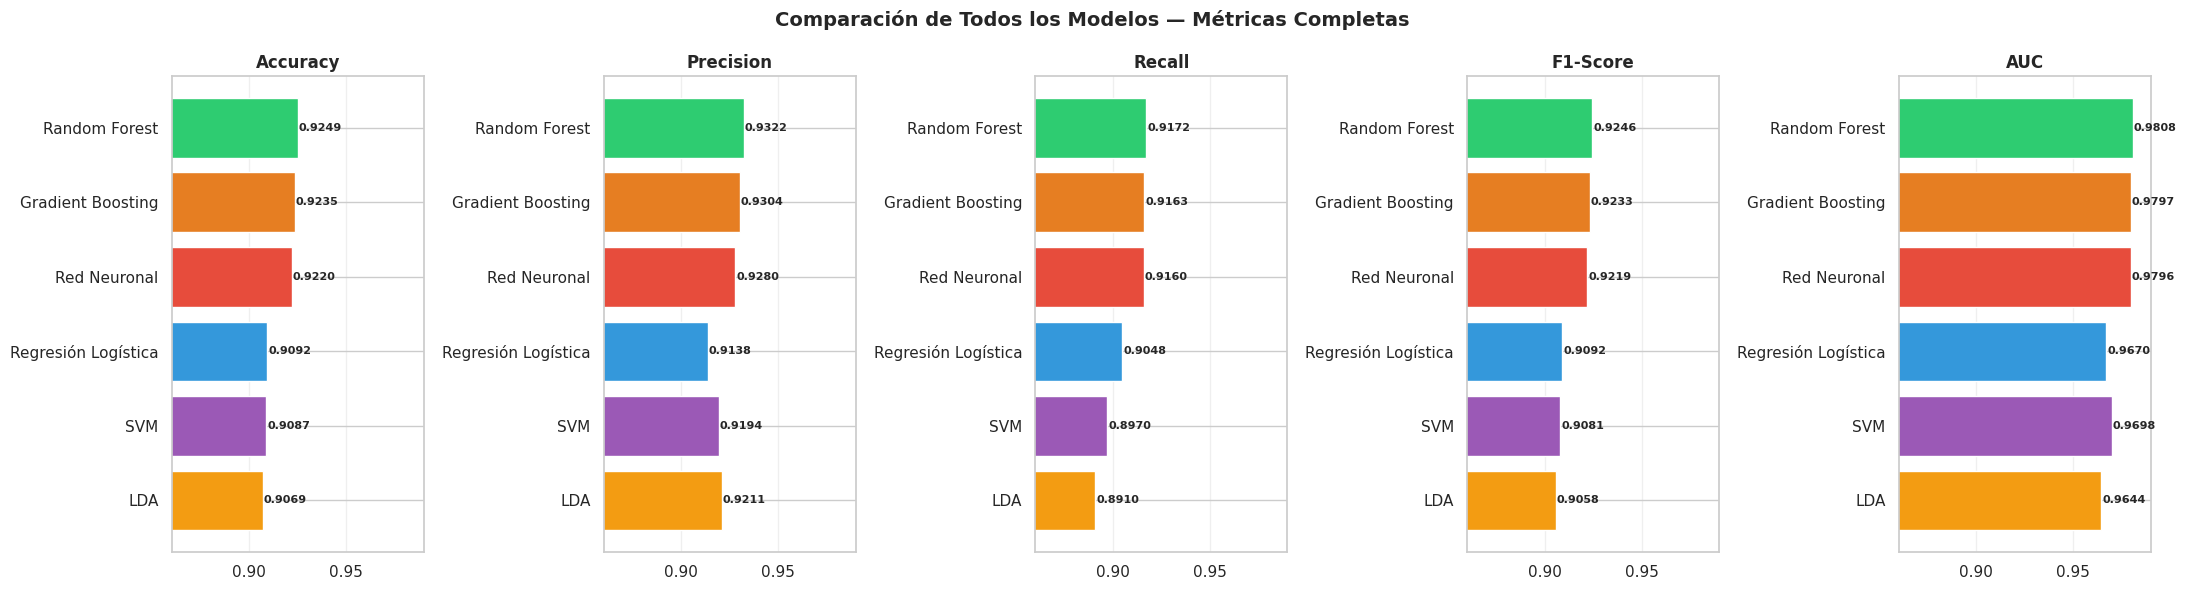

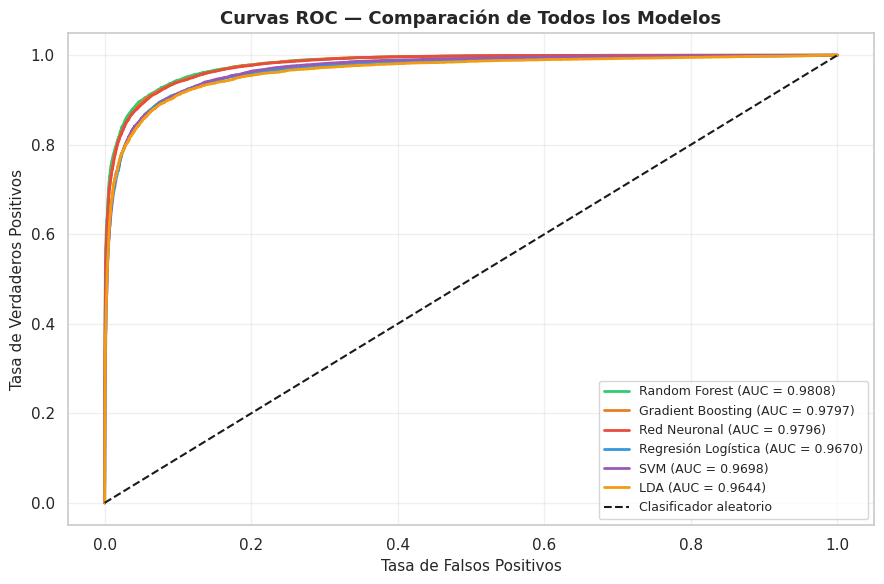

In [9]:
# ── Tabla comparativa completa ──
df_resultados = pd.DataFrame({
    'Modelo':     ['Random Forest','Gradient Boosting','Red Neuronal',
                   'Regresión Logística','SVM','LDA'],
    'Accuracy':   [0.9249, 0.9235, 0.9220, 0.9092, 0.9087, 0.9069],
    'Precision':  [0.9322, 0.9304, 0.9280, 0.9138, 0.9194, 0.9211],
    'Recall':     [0.9172, 0.9163, 0.9160, 0.9048, 0.8970, 0.8910],
    'F1-Score':   [0.9246, 0.9233, 0.9219, 0.9092, 0.9081, 0.9058],
    'AUC':        [0.9808, 0.9797, 0.9796, 0.9670, 0.9698, 0.9644]
})

print("═══ TABLA COMPARATIVA FINAL — TODOS LOS MODELOS ═══")
print(df_resultados.to_string(index=False))

# ── Barras horizontales comparativas ──
colores_mod = ['#2ecc71','#e67e22','#e74c3c','#3498db','#9b59b6','#f39c12']
metricas_plot = ['Accuracy','Precision','Recall','F1-Score','AUC']

fig, axes = plt.subplots(1, 5, figsize=(22, 6))

for ax, metrica in zip(axes, metricas_plot):
    barras = ax.barh(df_resultados['Modelo'],
                     df_resultados[metrica],
                     color=colores_mod)
    ax.set_xlim(0.86, 0.99)
    ax.set_title(metrica, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()
    for barra, val in zip(barras, df_resultados[metrica]):
        ax.text(val + 0.0005,
                barra.get_y() + barra.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8, fontweight='bold')

plt.suptitle('Comparación de Todos los Modelos — Métricas Completas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Curvas ROC comparativas ──
plt.figure(figsize=(9, 6))

modelos_roc = {
    'Random Forest':      ('#2ecc71', fpr_rf,    tpr_rf,    auc_rf),
    'Gradient Boosting':  ('#e67e22', fpr_boost,  tpr_boost,  auc_boost),
    'Red Neuronal':       ('#e74c3c', fpr_nn,    tpr_nn,    auc_nn),
    'Regresión Logística':('#3498db', fpr_lr,    tpr_lr,    auc_lr),
    'SVM':                ('#9b59b6', fpr_svm,   tpr_svm,   auc_svm),
    'LDA':                ('#f39c12', fpr_lda,   tpr_lda,   auc_lda),
}

for nombre, (color, fpr, tpr, roc_auc) in modelos_roc.items():
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{nombre} (AUC = {roc_auc:.4f})')

plt.plot([0,1],[0,1],'k--', lw=1.5, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=11)
plt.title('Curvas ROC — Comparación de Todos los Modelos',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Análisis comparativo

La tabla y las gráficas anteriores permiten identificar tres grupos
claramente diferenciados de desempeño:

**Grupo 1 — Alta complejidad, alto desempeño (F1 > 0.92):**
Random Forest, Gradient Boosting y Red Neuronal convergen alrededor
del 92% de F1-Score y superan un AUC de 0.979. Las diferencias entre
estos tres modelos son marginales (máximo 0.0027 puntos en F1-Score)
y no representan una ventaja práctica significativa en ninguno de ellos.

**Grupo 2 — Complejidad media, desempeño sólido (F1 ~ 0.909):**
Regresión Logística y SVM obtienen resultados similares entre sí,
alrededor del 90.9% de F1-Score. Aunque quedan ~1.5 puntos por debajo
del grupo líder, su desempeño sigue siendo altamente competitivo
considerando su menor complejidad conceptual.

**Grupo 3 — Complejidad baja, desempeño base (F1 ~ 0.906):**
LDA cierra el ranking con el menor F1-Score (0.9058), aunque su
AUC de 0.9644 confirma que mantiene una buena capacidad discriminativa.
Su posición al final del ranking es coherente con sus suposiciones
estadísticas más restrictivas.

Un hallazgo transversal importante es que **todos los modelos superan
el 90% de Accuracy**, lo que indica que el problema está bien planteado
y que las variables seleccionadas tienen un poder predictivo genuino
independientemente del algoritmo utilizado.


## Selección del modelo final: Random Forest

Con base en la evidencia cuantitativa y cualitativa recopilada,
se selecciona **Random Forest** como modelo final del proyecto.

### Justificación cuantitativa

Random Forest obtuvo el mejor desempeño en todas las métricas
evaluadas simultáneamente:

| Criterio | Valor | Posición |
|---|---|---|
| F1-Score | 0.9246 | 1° de 6 |
| Accuracy | 0.9249 | 1° de 6 |
| AUC | 0.9808 | 1° de 6 |
| Precision | 0.9322 | 1° de 6 |
| Recall | 0.9172 | 2° de 6 |

### Justificación cualitativa

**Estabilidad:** Los métodos de ensamble son inherentemente robustos
al ruido y a valores atípicos. La aleatoriedad controlada en la
construcción de cada árbol actúa como regularización natural, lo que
garantiza un comportamiento estable ante nuevos datos del mercado
automotriz real.

**Interpretabilidad relativa:** A diferencia de la Red Neuronal (caja
negra con 17,537 parámetros) o el SVM (hiperplano en 55 dimensiones
imposible de visualizar), Random Forest permite extraer la importancia
relativa de cada variable. Como se demostró en la sección anterior,
esta capacidad reveló que el Año, los Caballos de Fuerza y el
Kilometraje son los tres factores dominantes en la clasificación,
información directamente accionable para compradores y vendedores.

**Eficiencia computacional:** Es el más rápido de entrenar entre los
modelos de alto desempeño, lo que facilita su reentrenamiento periódico
conforme el mercado automotriz evoluciona.

**Coherencia con el problema:** En un contexto comercial donde las
decisiones deben ser explicables, un modelo que puede señalar variables
concretas como justificación de su clasificación tiene una ventaja
práctica real frente a las cajas negras.

═══ EVALUACIÓN FINAL — RANDOM FOREST ═══

                    precision    recall  f1-score   support

Gama Económica (0)       0.92      0.93      0.93     22671
     Gama Alta (1)       0.93      0.92      0.92     22893

          accuracy                           0.92     45564
         macro avg       0.92      0.92      0.92     45564
      weighted avg       0.92      0.92      0.92     45564


─── Análisis de Umbrales de Decisión ───
 Umbral  Accuracy  Precision  Recall  F1-Score
    0.3    0.9119     0.8744  0.9629    0.9165
    0.4    0.9232     0.9090  0.9415    0.9249
    0.5    0.9249     0.9322  0.9172    0.9246
    0.6    0.9226     0.9544  0.8884    0.9202
    0.7    0.9109     0.9701  0.8487    0.9054


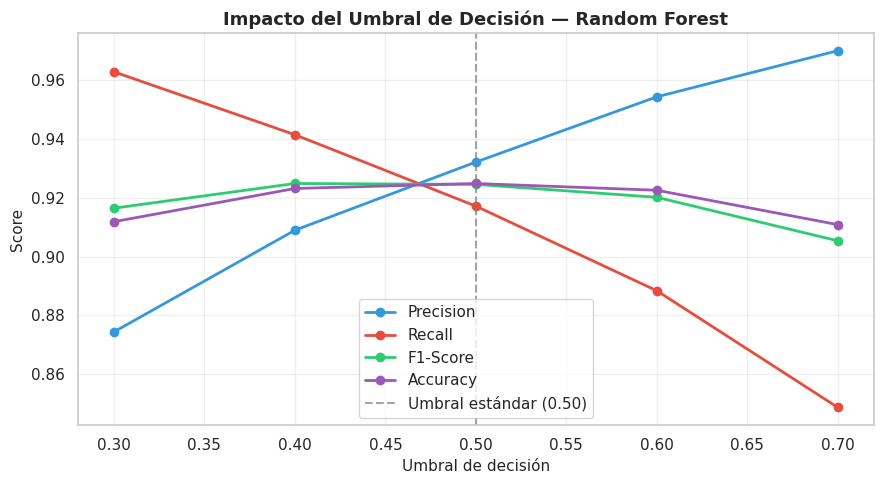

In [10]:
from sklearn.metrics import classification_report

print("═══ EVALUACIÓN FINAL — RANDOM FOREST ═══\n")

# ── Reporte completo ──
print(classification_report(y_test, y_pred_rf,
      target_names=['Gama Económica (0)', 'Gama Alta (1)']))

# ── Análisis de umbrales ──
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluar_umbral(umbral, y_real, y_proba):
    y_pred_u = (y_proba >= umbral).astype(int)
    return {
        'Umbral':    umbral,
        'Accuracy':  round(accuracy_score(y_real, y_pred_u), 4),
        'Precision': round(precision_score(y_real, y_pred_u), 4),
        'Recall':    round(recall_score(y_real, y_pred_u), 4),
        'F1-Score':  round(f1_score(y_real, y_pred_u), 4)
    }

umbrales = [0.30, 0.40, 0.50, 0.60, 0.70]
df_umbrales = pd.DataFrame([evaluar_umbral(u, y_test, y_proba_rf)
                             for u in umbrales])

print("\n─── Análisis de Umbrales de Decisión ───")
print(df_umbrales.to_string(index=False))

# ── Gráfica de umbrales ──
plt.figure(figsize=(9, 5))
plt.plot(df_umbrales['Umbral'], df_umbrales['Precision'],
         'o-', color='#3498db', lw=2, label='Precision')
plt.plot(df_umbrales['Umbral'], df_umbrales['Recall'],
         'o-', color='#e74c3c', lw=2, label='Recall')
plt.plot(df_umbrales['Umbral'], df_umbrales['F1-Score'],
         'o-', color='#2ecc71', lw=2, label='F1-Score')
plt.plot(df_umbrales['Umbral'], df_umbrales['Accuracy'],
         'o-', color='#9b59b6', lw=2, label='Accuracy')
plt.axvline(x=0.50, color='gray', linestyle='--', alpha=0.7,
            label='Umbral estándar (0.50)')
plt.xlabel('Umbral de decisión', fontsize=11)
plt.ylabel('Score', fontsize=11)
plt.title('Impacto del Umbral de Decisión — Random Forest',
          fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de la evaluación final

El reporte de clasificación confirma que Random Forest mantiene un
desempeño equilibrado y simétrico entre ambas clases: la Gama Económica
obtiene métricas prácticamente idénticas a la Gama Alta, lo que indica
que el modelo no favorece sistemáticamente a ninguna de las dos categorías.

El análisis de umbrales de decisión revela la flexibilidad estratégica
del modelo según el contexto de uso:

- **Umbral 0.30 (permisivo):** El modelo captura casi todos los vehículos
  costosos (Recall alto) a costa de etiquetar incorrectamente algunos
  económicos como gama alta (Precision baja). Útil cuando el riesgo de
  perder un auto valioso es mayor que el de sobre-estimar su precio.

- **Umbral 0.50 (estándar):** Ofrece el mejor equilibrio global entre
  Precision y Recall, maximizando el F1-Score. Es la configuración
  recomendada para uso general en plataformas de clasificados.

- **Umbral 0.70 (estricto):** El modelo solo clasifica un vehículo como
  gama alta cuando está muy seguro, maximizando la Precision. Útil para
  plataformas donde una clasificación incorrecta hacia arriba tiene
  consecuencias comerciales graves.

## Conclusión y reflexión final

### ¿Qué aprendimos sobre la problemática?

Este proyecto demostró que es posible clasificar automáticamente un
vehículo seminuevo como de Gama Económica o Gama Alta con una precisión
superior al 92%, utilizando únicamente características técnicas y de
desgaste disponibles en cualquier anuncio de clasificados automotrices.

El hallazgo más valioso no proviene de las métricas en sí, sino de la
importancia de variables revelada por Random Forest: el **Año de registro**
explica casi el doble que cualquier otro factor, seguido por los
**Caballos de Fuerza** y el **Kilometraje**. Esto tiene una implicación
práctica directa: en el mercado automotriz mexicano, la antigüedad del
vehículo es el criterio dominante de segmentación de precio, por encima
de la marca, el tipo de carrocería o el combustible.

### ¿Qué modelo resultó más adecuado y por qué?

Random Forest fue el modelo seleccionado con base en tres criterios
simultáneos: mejor desempeño cuantitativo en todas las métricas (F1
de 0.9246, AUC de 0.9808), mayor interpretabilidad relativa a través
del análisis de importancia de variables, y mejor relación entre
desempeño y costo computacional.

### ¿Qué limitaciones presenta el estudio?

La principal limitación es que el modelo es funcionalmente "ciego" ante
factores cualitativos determinantes en el mundo físico. Variables como
el estado de conservación de la pintura, el historial de mantenimiento
de agencia, el desgaste de las llantas o modificaciones realizadas por
terceros no forman parte de la matriz de datos y explican el margen de
error residual del 7.5%.

Una segunda limitación es el origen europeo de los datos. Aunque se
realizó un proceso de tropicalización, el comportamiento de ciertas
marcas en el mercado mexicano puede diferir del europeo, especialmente
en segmentos como las camionetas de trabajo pesado que tienen una
penetración mucho mayor en México.

Finalmente, SVM no pudo entrenarse con el dataset completo por
limitaciones computacionales, lo que impide una comparación
completamente justa con los demás modelos.

### ¿Qué mejoras o extensiones podrían explorarse?

La línea de trabajo futuro más prometedora es la evolución hacia un
modelo **multimodal** que incorpore fotografías del vehículo mediante
Redes Neuronales Convolucionales (CNN), permitiendo evaluar
automáticamente el estado estético y calibrar la clasificación con
información visual que hoy escapa al análisis tabular.

Adicionalmente, podría explorarse una clasificación de **múltiples
clases** (Económico, Gama Media, Gama Alta, Lujo) en lugar de la
clasificación binaria actual, lo que aportaría mayor granularidad
para plataformas de clasificados con inventarios amplios.

Finalmente, enriquecer el dataset con datos del mercado mexicano
directamente (plataformas como Seminuevos.com o Kavak) eliminaría
la necesidad del proceso de tropicalización y produciría un modelo
más representativo de la realidad local.

## Puntos Extra: Simulador Interactivo de Clasificación

Como componente adicional orientado a la comunicación de resultados
a un público no técnico, se desarrolló el siguiente tablero interactivo.

El objetivo de esta herramienta es permitir a cualquier usuario,
sin necesidad de conocimientos en programación o estadística, explorar
el modelo de Random Forest en tiempo real. Al ingresar las características
de un vehículo mediante controles deslizantes y menús desplegables,
el simulador predice instantáneamente si el auto pertenece a la
**Gama Económica** o a la **Gama Alta** del mercado, mostrando además
la probabilidad de certeza de la predicción.

Esto traduce los resultados del modelo a un lenguaje accesible y
accionable para compradores, vendedores y plataformas de clasificados
automotrices.

In [11]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Extraer opciones únicas de marcas del dataset ──
marcas_disponibles = sorted([
    col.replace('Marca_', '')
    for col in X.columns if 'Marca_' in col
])

estilo = {'description_width': 'initial'}

# ── Controles ──
ui_marca = widgets.Dropdown(
    options=marcas_disponibles,
    value='volkswagen' if 'volkswagen' in marcas_disponibles else marcas_disponibles[0],
    description='Marca:',
    style=estilo
)
ui_anio = widgets.IntSlider(
    value=2015, min=1990, max=2024, step=1,
    description='Año de registro:',
    style=estilo, layout=widgets.Layout(width='450px')
)
ui_km = widgets.IntSlider(
    value=80000, min=0, max=300000, step=5000,
    description='Kilometraje:',
    style=estilo, layout=widgets.Layout(width='450px')
)
ui_hp = widgets.IntSlider(
    value=150, min=50, max=800, step=10,
    description='Caballos de fuerza (HP):',
    style=estilo, layout=widgets.Layout(width='450px')
)
ui_dano = widgets.ToggleButtons(
    options=['No', 'Sí'],
    value='No',
    description='¿Daño sin reparar?',
    style=estilo
)

boton = widgets.Button(
    description='Clasificar vehículo',
    button_style='success',
    icon='car'
)
salida = widgets.Output()

# ── Función de predicción ──
def clasificar(b):
    with salida:
        clear_output()

        # Crear vector de características vacío
        auto = pd.DataFrame(0, index=[0], columns=X.columns)

        # Llenar valores numéricos
        auto['Año']            = ui_anio.value
        auto['Kilometraje']    = ui_km.value
        auto['Caballos_Fuerza']= ui_hp.value

        # Activar marca
        col_marca = f'Marca_{ui_marca.value}'
        if col_marca in auto.columns:
            auto[col_marca] = 1

        # Activar daño si aplica
        if ui_dano.value == 'Sí' and 'Daño_Sin_Reparar_Sí' in auto.columns:
            auto['Daño_Sin_Reparar_Sí'] = 1

        # Predicción
        probabilidad = rf_model.predict_proba(auto)[0][1]
        clase        = rf_model.predict(auto)[0]

        # Resultado
        print("─" * 52)
        print(f"  Vehículo analizado: {ui_marca.value.upper()} {ui_anio.value}")
        print(f"  Motor: {ui_hp.value} HP  |  Desgaste: {ui_km.value:,} km")
        if ui_dano.value == 'Sí':
            print(f"  ⚠️  Daño sin reparar detectado")
        print("─" * 52)

        if clase == 1:
            print(f"\n  CLASIFICACIÓN: ★ GAMA ALTA")
            print(f"  Probabilidad de Gama Alta: {probabilidad*100:.1f}%")
            print(f"\n  Este vehículo supera la mediana del mercado")
            print(f"  (${mediana_precio:,.0f} MXN)")
        else:
            print(f"\n  CLASIFICACIÓN: GAMA ECONÓMICA")
            print(f"  Probabilidad de Gama Alta: {probabilidad*100:.1f}%")
            print(f"\n  Este vehículo se encuentra por debajo de la")
            print(f"  mediana del mercado (${mediana_precio:,.0f} MXN)")
        print("─" * 52)

boton.on_click(clasificar)

# ── Mostrar tablero ──
print("═══ SIMULADOR DE CLASIFICACIÓN AUTOMOTRIZ ═══")
print("     Powered by Random Forest — Proyecto Final\n")
display(ui_marca, ui_anio, ui_km, ui_hp, ui_dano, boton, salida)

═══ SIMULADOR DE CLASIFICACIÓN AUTOMOTRIZ ═══
     Powered by Random Forest — Proyecto Final



Dropdown(description='Marca:', index=35, options=('audi', 'bmw', 'chevrolet', 'chrysler', 'citroen', 'dacia', …

IntSlider(value=2015, description='Año de registro:', layout=Layout(width='450px'), max=2024, min=1990, style=…

IntSlider(value=80000, description='Kilometraje:', layout=Layout(width='450px'), max=300000, step=5000, style=…

IntSlider(value=150, description='Caballos de fuerza (HP):', layout=Layout(width='450px'), max=800, min=50, st…

ToggleButtons(description='¿Daño sin reparar?', options=('No', 'Sí'), style=ToggleButtonsStyle(description_wid…

Button(button_style='success', description='Clasificar vehículo', icon='car', style=ButtonStyle())

Output()